# VAR

In [1]:
params_path <- '../../data/model_in/parameters_for_model_curated_2569-31-01-25.tsv'
clust_file <- '../../data/model_in/clust.faa.clstr'
map_file <- '../../data/model_in/final.map'
exp_fla_file <- '../../data/model_in/experimental_flagellins.fasta'

# Init

In [2]:
library(ggplot2)
library(rpart)
library(splitTools)
library(tibble)
library(randomForest)
library(caret)
library(cvms)
library(nestedcv)
library(ggsci)
library(ggrepel)
library(ggforce)
library(dplyr)
library(tidyverse)
library(LeyLabRMisc)
library(tidyr)
library(purrr)
library(readr)
library(pwalign)
library(Biostrings)
library(gridExtra)
library(ggpubr)
library(pROC)

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


Loading required package: lattice


Attaching package: ‘dplyr’


The following object is masked from ‘package:randomForest’:

    combine


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ readr     2.1.5
✔ lubridate 1.9.4     ✔ stringr   1.5.2
✔ purrr     1.1.0     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::combine()       masks randomForest::combine()
✖ dplyr::filter()        masks stats::filter()
✖ dplyr::lag()           masks stats::lag()
✖ purrr::lift()          masks caret::lift()
✖ randomForest::margin() masks ggp

In [3]:
source('./model_notebook_functions.R')

In [4]:
df.dims(3)

# Load

In [5]:
# Load information about clusters

lines <- readLines(clust_file)

protein_names <- c()
cluster_ids <- c()
current_cluster <- NULL

for (line in lines) {
  if (grepl("^>Cluster", line)) {
    
    current_cluster <- strsplit(line, " ")[[1]][2] # get the cluster number
  } else {
    if (!is.null(current_cluster)) {
      protein_name <- sub(".*, >", "", line)
      protein_name <- sub("\\s.*", "", protein_name)
      protein_names <- c(protein_names, protein_name)
      cluster_ids <- c(cluster_ids, current_cluster)
    }
  }
}


df_clusters <- data.frame(Flagellin_ID = protein_names, Cluster_CDHit = cluster_ids)

df_clusters <- df_clusters %>% 
                arrange(Flagellin_ID) %>% 
                mutate(Flagellin_ID = str_replace_all(Flagellin_ID, "\\...", ""))
df_clusters

Flagellin_ID,Cluster_CDHit
<chr>,<chr>
AAA23797_1,86
AAA23798_1,101
⋮,⋮
sp|P42273_1|FLIC2_PROMI,926


In [6]:
df <- read.table(params_path, sep = "\t", header = TRUE, row.names = 1)
df <- df %>% mutate(avg.activity = gsub(',', '.', avg.activity),
                avg.activity = as.numeric(avg.activity),
                avg.binding = gsub(',', '.', avg.binding),
                avg.binding = as.numeric(avg.binding))
colnames(df)

[1] "R.K478_r_k"            "E78_charge"            "L88_charge"           
 [4] "Q89_charge"            "R90_charge"            "L94_charge"           
 [7] "A95_charge"            "Q97_charge"            "N100_charge"          
[10] "S101_charge"           "N103_charge"           "S104_charge"          
[13] "A113_charge"           "T116_charge"           "Q117_charge"          
[16] "I422_charge"           "V439_charge"           "Q440_charge"          
[19] "S445_charge"           "A446_charge"           "I447_charge"          
[22] "N449_charge"           "R.K478_charge"         "E78_hydrophobicity"   
[25] "L88_hydrophobicity"    "Q89_hydrophobicity"    "R90_hydrophobicity"   
[28] "L94_hydrophobicity"    "A95_hydrophobicity"    "Q97_hydrophobicity"   
[31] "N100_hydrophobicity"   "S101_hydrophobicity"   "N103_hydrophobicity"  
[34] "S104_hydrophobicity"   "A113_hydrophobicity"   "T116_hydrophobicity"  
[37] "Q117_hydrophobicity"   "I422_hydrophobicity"   "V439_hydrophobicity"  
[40] "Q440_hydrophobicity"   "S445_hydrophobicity"   "A446_hydrophobicity"  
[43] "I447_hydrophobicity"   "N449_hydrophobicity"   "R.K478_hydrophobicity"
[46] "pident_FlaB"           "length_FlaB"           "mismatch_FlaB"        
[49] "pident_FliC"           "length_FliC"           "mismatch_FliC"        
[52] "alntmscore_foldseek"   "rmsd_foldseek"         "avg.activity"         
[55] "avg.binding"           "Exp.phenotype"

In [7]:
splits <- c(1234567, 7654321, 1357642, 2467531, 4321567, 4567321, 1234, 4567, 7654, 4321)

# 1 Preprocessing

## 1.1 Add info about clusters and sequences for splitting

In [8]:
df_clust <- df %>% rownames_to_column(var = 'Flagellin_ID') %>% left_join(df_clusters, by = "Flagellin_ID")
'Cluster_CDHit' %in% colnames(df_clust)

[1] TRUE

In [9]:
df_clust_seq <- merge_fasta_with_df(exp_fla_file, df_clust)
df_clust_seq <- df_clust_seq %>% column_to_rownames(var = 'Flagellin_ID')
df_clust_seq

,R.K478_r_k,E78_charge,L88_charge,Q89_charge,R90_charge,L94_charge,A95_charge,Q97_charge,N100_charge,S101_charge,⋯,pident_FliC,length_FliC,mismatch_FliC,alntmscore_foldseek,rmsd_foldseek,avg.activity,avg.binding,Exp.phenotype,Cluster_CDHit,sequence
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
SAE38355_1,1,-1,0,0,1,0,0,0,0,0,⋯,76.0,179,43,0.8947,4.831,NA,NA,NA,959,NA
SAB91600_1,1,-1,0,0,1,0,0,0,0,0,⋯,76.5,179,42,0.8943,4.899,NA,NA,NA,960,NA
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
PWM92012_1,0,0,0,0,0,0,0,0,-1,-1,⋯,NA,NA,NA,0.7468,20.39,-6,0,evader,897,MADISLTASMRSNLLSLQNTQSLMDMTQERLSTGKKVNSALDNPTSYYTSQSLTNRASDLSALLDSMGQGIQTIKAANEGIESITEFVQQAKSVANQARDEANKVAGSTGNYDAEKIEADTEFNITVTYNGETKSEQVTLTDAKTSGADAASEIQDVLQAMEFGADSTALGTNYTVTFEDGAFKVNSANGEEIKISFEVGGAKMDASAGNANRVKAISQFNDILDQIDQLAKDSGYKGVNLLGGTDQSLTVIFNEDRSSNLTIQGVDASTKGLDISRVTDWGSNTNIDASIEEVEDAINELRNMASEFGNNYSIVQNREDFTENLINVLEEGSDKLVLADMNEESANMLALQTRQQLGVNSLSLASQAAQAVLKLF


## 1.2 Assess variance of the features on the whole dataset

In [10]:
# calculate variance
param_cols <- names(df_clust_seq)[!(names(df_clust_seq) %in% c("Exp.phenotype", "Cluster_CDHit", "sequence", 'pident_FlaB', 'length_FlaB', 'mismatch_FlaB', 'pident_FliC', 'length_FliC', 'mismatch_FliC', 'alntmscore_foldseek', 'rmsd_foldseek', 'avg.activity', 'avg.binding'))]
var_values <- sapply(df_clust_seq[param_cols], function(x) {
  x_clean <- suppressWarnings(as.numeric(as.character(x)))
  if(all(is.na(x_clean))) return(NA)
  return(var(x_clean, na.rm = TRUE))
})

# for plotting
var_df <- data.frame(
  Parameter = names(var_values),
  Variance = var_values
)

# Get parameter order based on variance
param_order <- var_df[order(-var_df$Variance), "Parameter"]
low_var_params <- var_df$Parameter[var_df$Variance < 0.01]

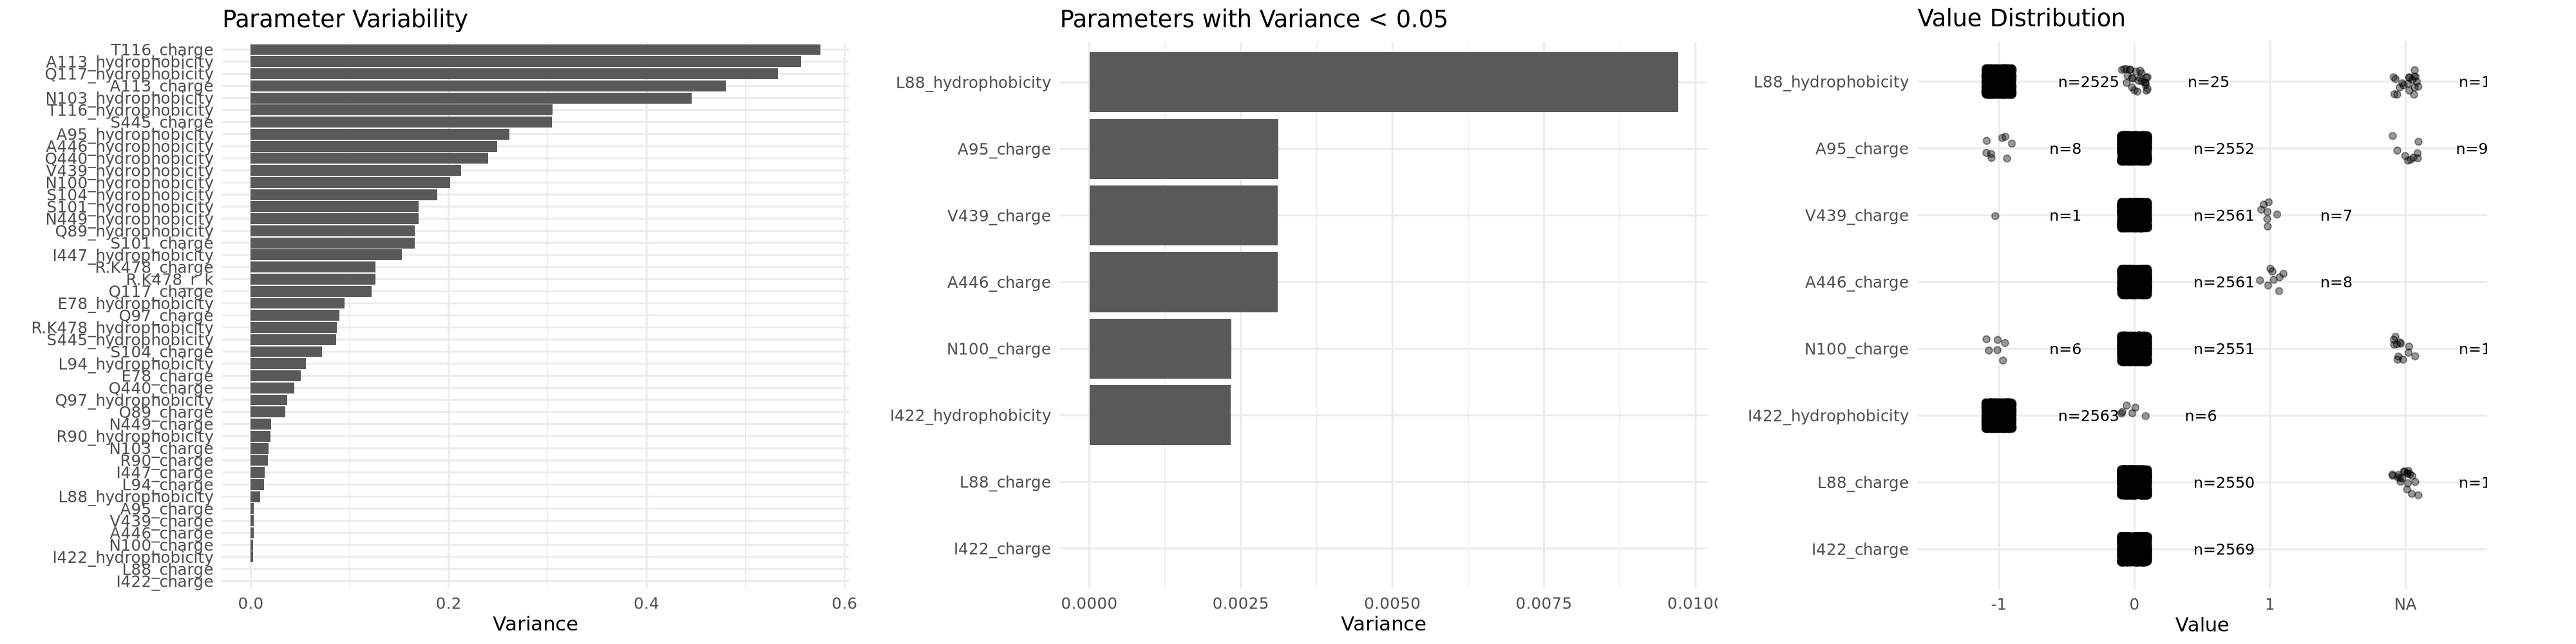

In [11]:
# Parameter Variability across almost all
p1 <- ggplot(var_df, aes(x = reorder(Parameter, Variance), y = Variance)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "Parameter Variability", x = "", y = "Variance") +
  theme_minimal()

# Paramaterers with Variance < threshold
p2 <- ggplot(var_df[var_df$Variance < 0.01,], 
       aes(x = reorder(Parameter, Variance), y = Variance)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "Parameters with Variance < 0.05", x = "", y = "Variance") +
  theme_minimal()

low_var_data <- df_clust_seq[, low_var_params] %>%
  gather(key = "Parameter", value = "Value") %>%
  mutate(Parameter = factor(Parameter, levels = rev(as.character(param_order))))

value_counts <- low_var_data %>%
  group_by(Parameter, Value) %>%
  summarize(Count = n(), .groups = 'drop')

# Values distribution
p3 <- ggplot() +
  geom_jitter(data = low_var_data, aes(x = factor(Value), y = Parameter), 
              alpha = 0.4, height = 0.2, width = 0.1) +
  geom_text(data = value_counts, 
            aes(x = factor(Value), y = Parameter, label = paste0("n=", Count)),
            hjust = -0.3, size = 3, position = position_nudge(x = 0.3)) +
  labs(title = "Value Distribution", x = "Value", y = "") +
  scale_x_discrete() +
  theme_minimal() +
  theme(plot.margin = unit(c(5, 50, 5, 5), "points"))

  
p.dims(20, 5)
grid.arrange(p1, p2, p3, ncol = 3)

In [12]:
df_cleaned_full <- df_clust_seq %>% select(-all_of(low_var_params))
ncol(df_cleaned_full)
nrow(df_cleaned_full)

[1] 50

[1] 2569

In [13]:
df_cleaned_full <- df_clust_seq # for v3

## 1.3 Handle NAs 
Current solution - discard rows with NAs


In [14]:
cat("N of ID's Before NA filtering:", nrow(df_cleaned_full), '\n')
# Check for NA values in df
na_indices <- df_cleaned_full %>% select(-c(sequence, Cluster_CDHit, Exp.phenotype, avg.activity, avg.binding))
na_indices <- as.data.frame(which(is.na(na_indices), arr.ind = TRUE))

#rownames(na_indices)
### temporary fix for NAs
df_cleaned_full_filtered <- df_cleaned_full %>% filter(!(rownames(.) %in% rownames(na_indices)))
cat("N of ID's After NA filtering:", nrow(df_cleaned_full_filtered))

N of ID's Before NA filtering: 2569 


N of ID's After NA filtering: 2464

## 1.4 Subset the dataset

* Keep only experimental data

In [15]:
df_exp_master <- df_cleaned_full_filtered %>% filter(Exp.phenotype != 0)
df_exp_master %>% group_by(Exp.phenotype) %>% count()

Exp.phenotype,n
<chr>,<int>
active,40
evader,27
silent,52


In [16]:
# exclude evaders since they are underrepresented
df_exp <- df_exp_master %>% filter(Exp.phenotype != 'evader') 

df_exp %>% group_by(Exp.phenotype) %>% count()
cat('Total number of flagellins:', nrow(df_exp))

Exp.phenotype,n
<chr>,<int>
active,40
silent,52


Total number of flagellins: 92

In [17]:
# remove, because:  binding and activity are experimental values
df_exp_model <- df_exp %>% select(-c(avg.binding, avg.activity))

c('avg.binding', 'avg.activity') %in% colnames(df_exp_model) # If false, then correct

[1] FALSE FALSE

In [18]:
df_exp_model_cleaned <- filter_low_variance(df_exp_model, 0)

* N of features initially: 56 
* N of features with variance <= 0 : 15 
* Namely: E78_charge L88_charge Q89_charge R90_charge L94_charge A95_charge I422_charge V439_charge A446_charge N449_charge E78_hydrophobicity L88_hydrophobicity R90_hydrophobicity L94_hydrophobicity Q97_hydrophobicity 
* N of features after filtration: 41

In [19]:
df_exp_model_cleaned <- df_exp # for v3

##  1.5 Split train and test

In [20]:
df_exp_model_cleaned <- df_exp_model_cleaned %>% select(-c(avg.binding, avg.activity))

In [21]:
result <- split_train_test(df_exp_model_cleaned, splits[10])
train <- result[[1]]
test <- result[[2]]

In [22]:
train <- train %>% select(-c(sequence, Cluster_CDHit))
test <- test %>% select(-c(Cluster_CDHit, sequence))

In [23]:
# summary
cat("Training set size:", nrow(train), "sequences\n")
cat("Testing set size:", nrow(test), "sequences\n")


# Get the numbers of the phenotype per test
if ("Exp.phenotype" %in% colnames(df_exp_model_cleaned)) {
  cat("\nPhenotype distribution in full dataset:\n")
  print(table(df_exp_model_cleaned$Exp.phenotype))
  
  cat("\nPhenotype distribution in training set:\n")
  print(table(train$Exp.phenotype))
  
  cat("\nPhenotype distribution in testing set:\n")
  print(table(test$Exp.phenotype))
}

Training set size: 64 sequences
Testing set size: 28 sequences

Phenotype distribution in full dataset:

active silent 
    40     52 

Phenotype distribution in training set:

active silent 
    28     36 

Phenotype distribution in testing set:

active silent 
    12     16 


# 2 Train model

In [24]:
res1 = train_model_nestedcv(train)

15 predictor(s) have var=0

Fitting final model using CV on whole data

Duration: 27.41394 secs



In [25]:
summary(res1)

Nested cross-validation with caret
Method:  method 
No filter
Outer loop:  10-fold cv
Inner loop:  10-fold cv
64 observations, 38 predictors
active silent 
    28     36 

         mtry  n.filter
Fold 1      2        38
Fold 2      2        38
Fold 3      2        38
Fold 4      2        38
Fold 5     38        38
Fold 6      2        38
Fold 7      2        38
Fold 8      2        38
Fold 9      2        38
Fold 10     2        38

Final parameters:
  mtry
     2

Result:
         Reference
Predicted active silent
   active     20      4
   silent      8     32

              AUC            Accuracy   Balanced accuracy   
           0.8130              0.8125              0.8016   


# 3 Test model

## 3.1 Predict the phenotype for the test dataset

In [26]:
test$pred1<-as.vector(predict(res1, newdata = test))

test

,R.K478_r_k,E78_charge,L88_charge,Q89_charge,R90_charge,L94_charge,A95_charge,Q97_charge,N100_charge,S101_charge,⋯,pident_FlaB,length_FlaB,mismatch_FlaB,pident_FliC,length_FliC,mismatch_FliC,alntmscore_foldseek,rmsd_foldseek,Exp.phenotype,pred1
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>
P0C6C4_VcFlaB,1,-1,0,0,1,0,0,0,0,0,⋯,37.5,104,65,45.2,168,91,0.9448,1.373,active,active
WP_118747250_1,1,-1,0,0,1,0,0,0,0,0,⋯,42.2,116,67,46.3,123,65,0.9366,3.133,silent,active
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
Q5Y831_LmFlaA,1,-1,0,0,1,0,0,0,0,0,⋯,32.7,98,66,39.7,174,100,0.9626,3.359,active,active


## 3.2 Assess the model

In [27]:
# Convert both predictions and actual outcomes to factors with the same levels
levels_to_use <- union(levels(test$Exp.phenotype), unique(test$pred1))

# Now calculate the confusion matrix
test$pred1 <- factor(test$pred1, levels = levels_to_use)
test$Exp.phenotype <- factor(test$Exp.phenotype, levels = levels_to_use)
conf_mat <- confusionMatrix(test$pred1, test$Exp.phenotype)
print(conf_mat)

Confusion Matrix and Statistics

          Reference
Prediction active silent
    active     10      2
    silent      2     14
                                          
               Accuracy : 0.8571          
                 95% CI : (0.6733, 0.9597)
    No Information Rate : 0.5714          
    P-Value [Acc > NIR] : 0.001268        
                                          
                  Kappa : 0.7083          
                                          
 Mcnemar's Test P-Value : 1.000000        
                                          
            Sensitivity : 0.8333          
            Specificity : 0.8750          
         Pos Pred Value : 0.8333          
         Neg Pred Value : 0.8750          
             Prevalence : 0.4286          
         Detection Rate : 0.3571          
   Detection Prevalence : 0.4286          
      Balanced Accuracy : 0.8542          
                                          
       'Positive' Class : active          
            

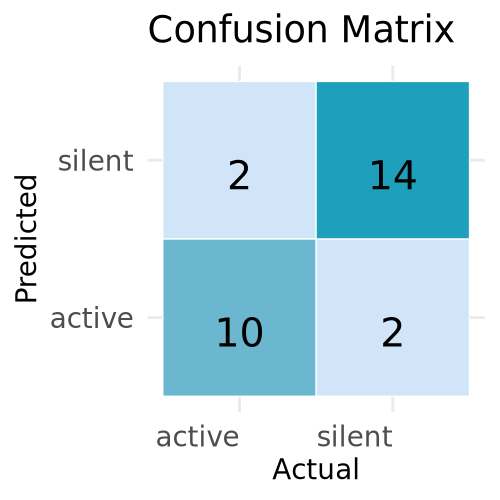

In [28]:
p.dims(2.5, 2.5)
confusion <- as.table(conf_mat$table)
p_cm = ggplot(data = as.data.frame(confusion), aes(x = Reference, y = Prediction, fill = Freq)) +
    geom_tile(color = "white") +
    geom_text(aes(label = sprintf("%1.0f", Freq)), vjust = 1, size = 5) +
    scale_fill_gradient(low = "#d0e6f8", high = "#1ea0bd") +
    theme_minimal() +
    theme(axis.text.x = element_text(hjust = 1, size = 10),
            axis.text=element_text(size=10),
            axis.title=element_text(size=10),
            #plot.title=element_text(size=5),
            #legend.text=element_text(size=5),
            legend.title=element_text(size=5)) +
    theme(legend.position = "none") + # delete legend title ) +
    labs(title = "Confusion Matrix", x = "Actual", y = "Predicted")
print(p_cm)


In [29]:
cat('The probability with which the model predicts a class for each observation in the test set.')
predict(res1, newdata = test, type = "prob")

The probability with which the model predicts a class for each observation in the test set.

,active,silent
,<dbl>,<dbl>
P0C6C4_VcFlaB,0.710,0.290
WP_118747250_1,0.624,0.376
⋮,⋮,⋮
Q5Y831_LmFlaA,0.526,0.474


### Figure 2b

In [30]:
# Get probability matrix
probs <- predict(res1, newdata = test, type = "prob")

test$pred1_prob <- probs[, "silent"]  # positive class

Setting levels: control = active, case = silent

Setting direction: controls < cases



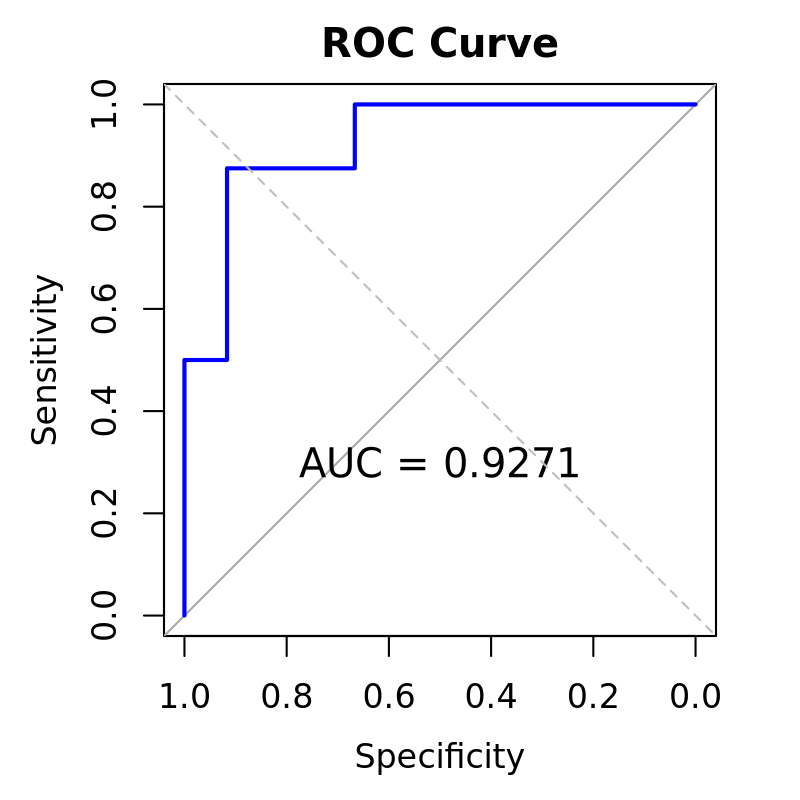

In [31]:
p.dims(4, 4)

roc_obj <- roc(test$Exp.phenotype, test$pred1_prob)

plot(roc_obj, 
     main = "ROC Curve",
     col = "blue", 
     lwd = 2)


text(0.5, 0.3, 
     paste("AUC =", round(auc(roc_obj), 4)), 
     cex = 1.2)

# Add random classifier
abline(a = 0, b = 1, lty = 2, col = "gray")

### SFigure 2 (Feature importance)

In [32]:
importance = cv_varImp(res1)
importance

,,,,,,,,,,,Final
R.K478_r_k,43.40454,32.06419,32.73431,30.034468,4.122825,36.59334,24.977965,38.369366,35.97902,32.87215,37.35488
Q97_charge,16.12368,13.01012,13.96710,9.539866,3.095947,10.47536,9.053298,9.576594,13.03505,12.37415,12.86606
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
rmsd_foldseek,70.62751,68.74395,57.3976,71.5418,23.71056,73.59963,63.95787,60.01129,56.67862,72.13647,70.80752


In [33]:
df_var <- var_stability(res1) 
df_var

,mean,sd,sem,frequency,sign,direction,final
,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<fct>,<fct>
pident_FliC,91.17598,11.84774,3.572228,11,-1,Up in active,yes
pident_FlaB,89.32183,19.78002,5.963901,11,1,Up in silent,yes
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
I422_hydrophobicity,0.2258174,0.6541394,0.1972304,2,1,Up in silent,yes


`height` was translated to `width`.


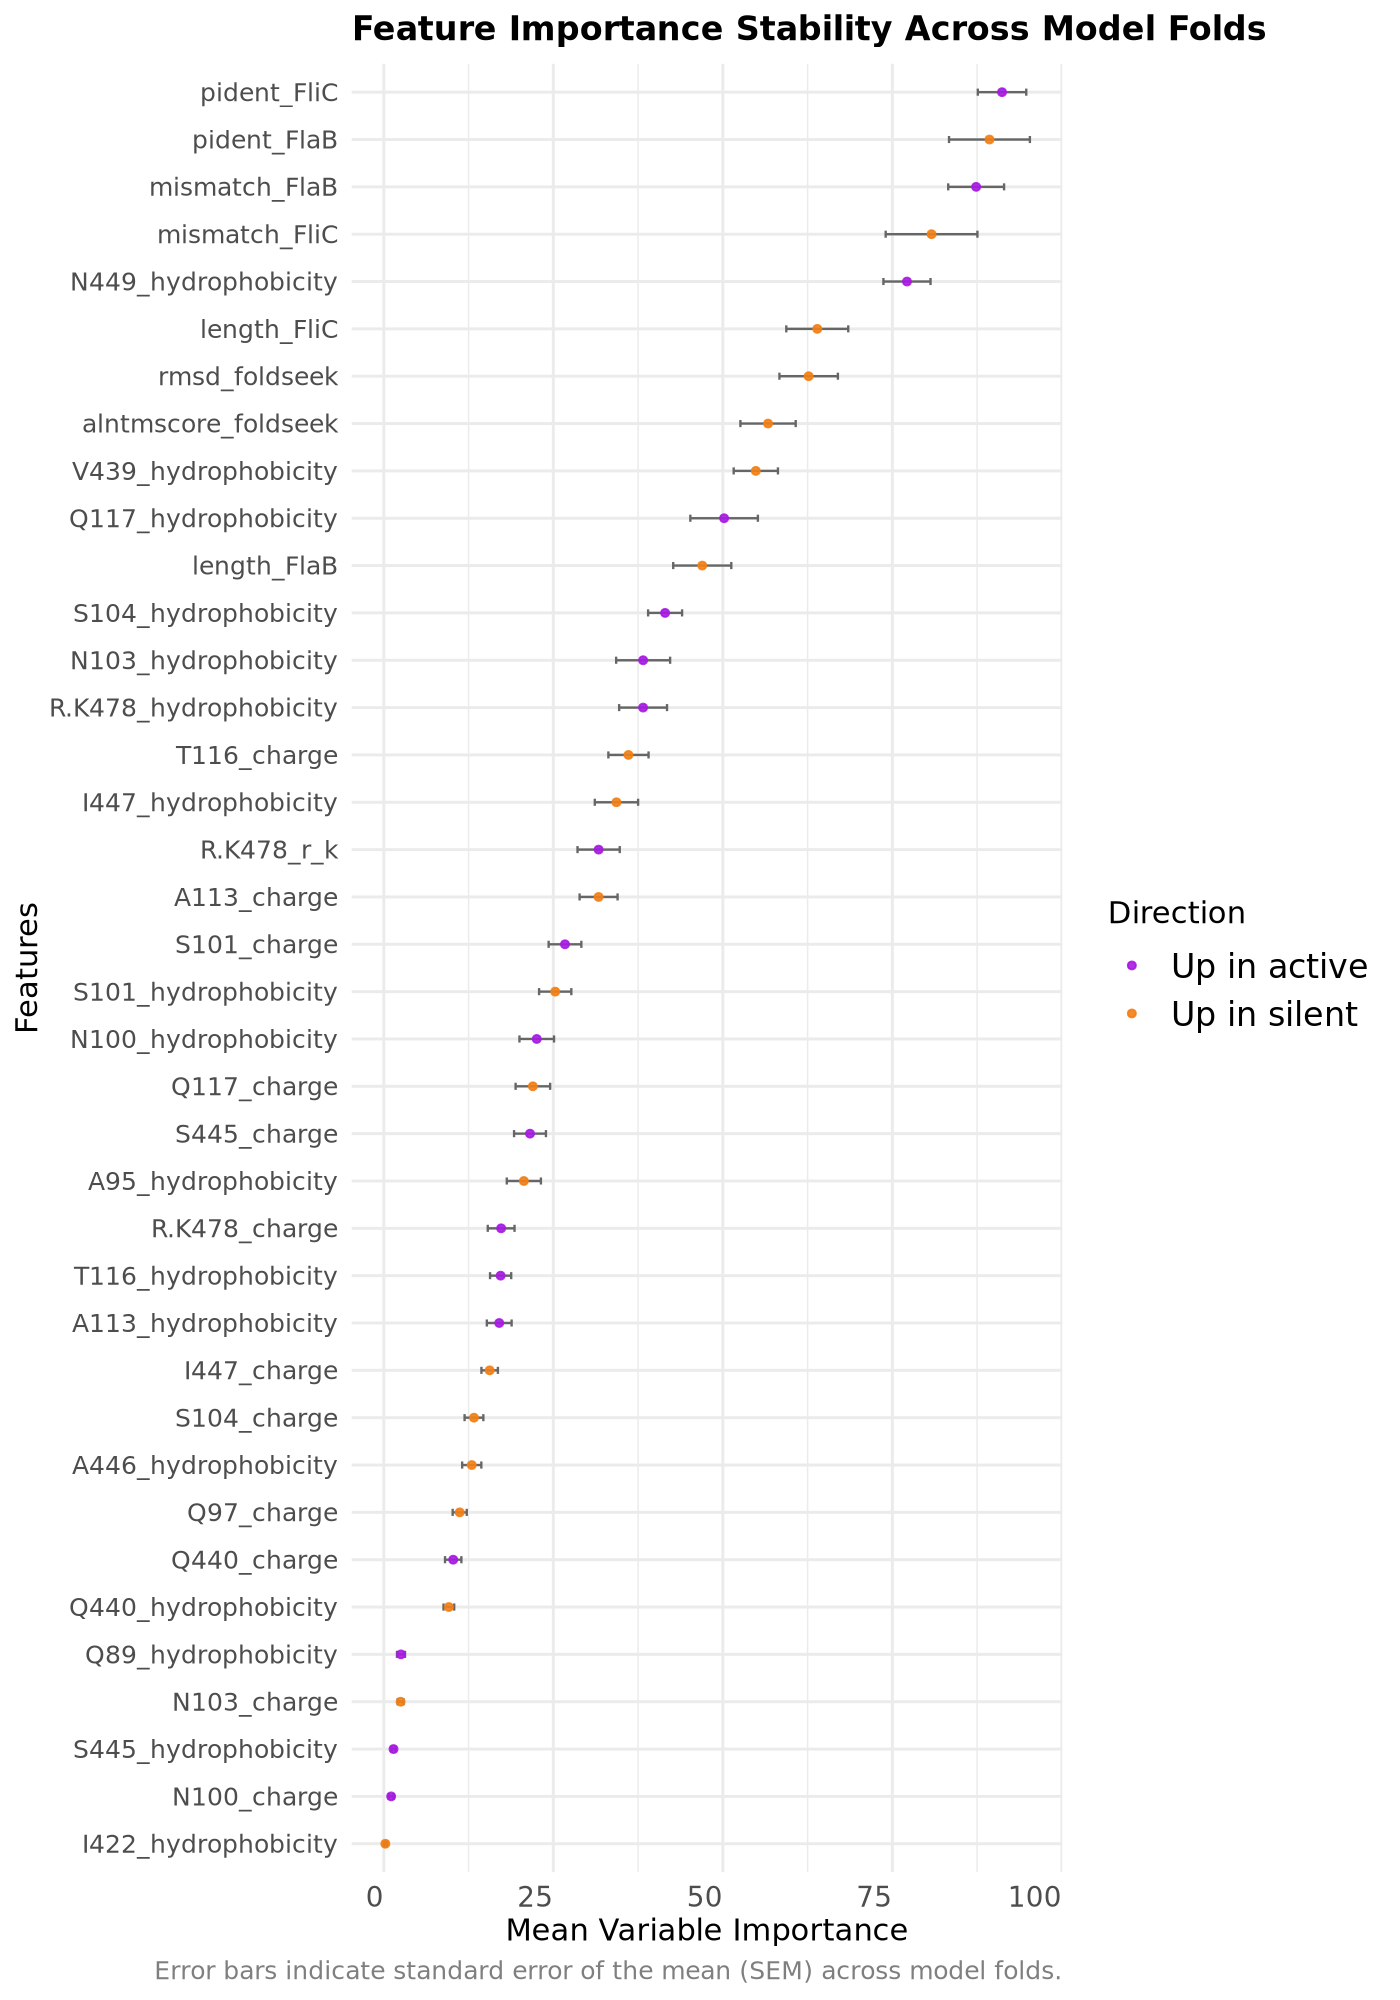

In [36]:
p.dims(7, 10)

# Define customizable parameters in advance for convenience
point_size <- 1.0          
errorbar_size <- 0.4       
errorbar_height <- 0.15    
point_alpha <- 0.9         

ggplot(df_var, aes(x = mean, y = reorder(rownames(df_var), mean))) +
  geom_errorbarh(aes(xmin = mean - sem, xmax = mean + sem), 
                 height = errorbar_height,
                 size = errorbar_size,
                 color = "gray40") + 
  geom_point(aes(color = direction), 
             size = point_size,
             alpha = point_alpha) +
  scale_color_manual(values = c("Up in active" = "#a71ae3", 
                               "Up in silent" = "#f18015")) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(hjust = 1, vjust = 1, size = 10),
    axis.text.y = element_text(size = 9),     # Slightly smaller for feature names
    axis.title = element_text(size = 11), 
    legend.text = element_text(size = 12),
    legend.title = element_text(size = 11),
    plot.title = element_text(size = 12, face = "bold"),
    plot.caption = element_text(size = 9, color = "gray50")
  ) +
  labs(
    title = "Feature Importance Stability Across Model Folds", 
    x = "Mean Variable Importance",
    y = "Features",
    color = "Direction",
    caption = "Error bars indicate standard error of the mean (SEM) across model folds."
  )

### Shuffle the labels

In [55]:
# Shuffling - move in the future

train_shuffle <- train

# shuffled the labels in the train dataset
train_shuffle[["Exp.phenotype"]] <- sample(train_shuffle[["Exp.phenotype"]])

res2 = train_model_nestedcv(train_shuffle)
summary(res2)

15 predictor(s) have var=0

Fitting final model using CV on whole data

Duration: 24.70677 secs



Nested cross-validation with caret
Method:  method 
No filter
Outer loop:  10-fold cv
Inner loop:  10-fold cv
64 observations, 38 predictors
active silent 
    28     36 

         mtry  n.filter
Fold 1      2        38
Fold 2      2        38
Fold 3      2        38
Fold 4      2        38
Fold 5      2        38
Fold 6      2        38
Fold 7      2        38
Fold 8      2        38
Fold 9      2        38
Fold 10     2        38

Final parameters:
  mtry
     2

Result:
         Reference
Predicted active silent
   active     13     16
   silent     15     20

              AUC            Accuracy   Balanced accuracy   
           0.5218              0.5156              0.5099   


In [ ]:
res <- evaluate_v3_robust(df_exp_model_cleaned, iterations = 100)
#saveRDS(res, "res_v3_100.rds")


In [74]:
res <- readRDS("res2_v3_100.rds")

In [123]:
results <- res %>% #rename(Method = 'Label') %>%
    mutate(Method = case_when(
        Method == 'random_cluster_shuffle' ~ 'shuffled_labels',
        Method == 'random_split' ~ 'correct_labels'
    ))


#### SFigure 3 b

In [ ]:
metrics_long <- results %>%
  select(Method, Iteration, TestAccuracy, Sensitivity, Specificity, 
         PPV, NPV, F1, BalancedAccuracy) %>%
  pivot_longer(cols = c(TestAccuracy, Sensitivity, Specificity, 
                        PPV, NPV, F1, BalancedAccuracy),
               names_to = "Metric", values_to = "Value")


y_positions <- metrics_long %>%
  group_by(Metric) %>%
  summarize(y.position = max(Value, na.rm = TRUE) * 1.15)

metrics_long <- metrics_long %>%
  left_join(y_positions, by = "Metric")

# Define comparisons
comparisons <- list(c("correct_labels", "shuffled_labels"))

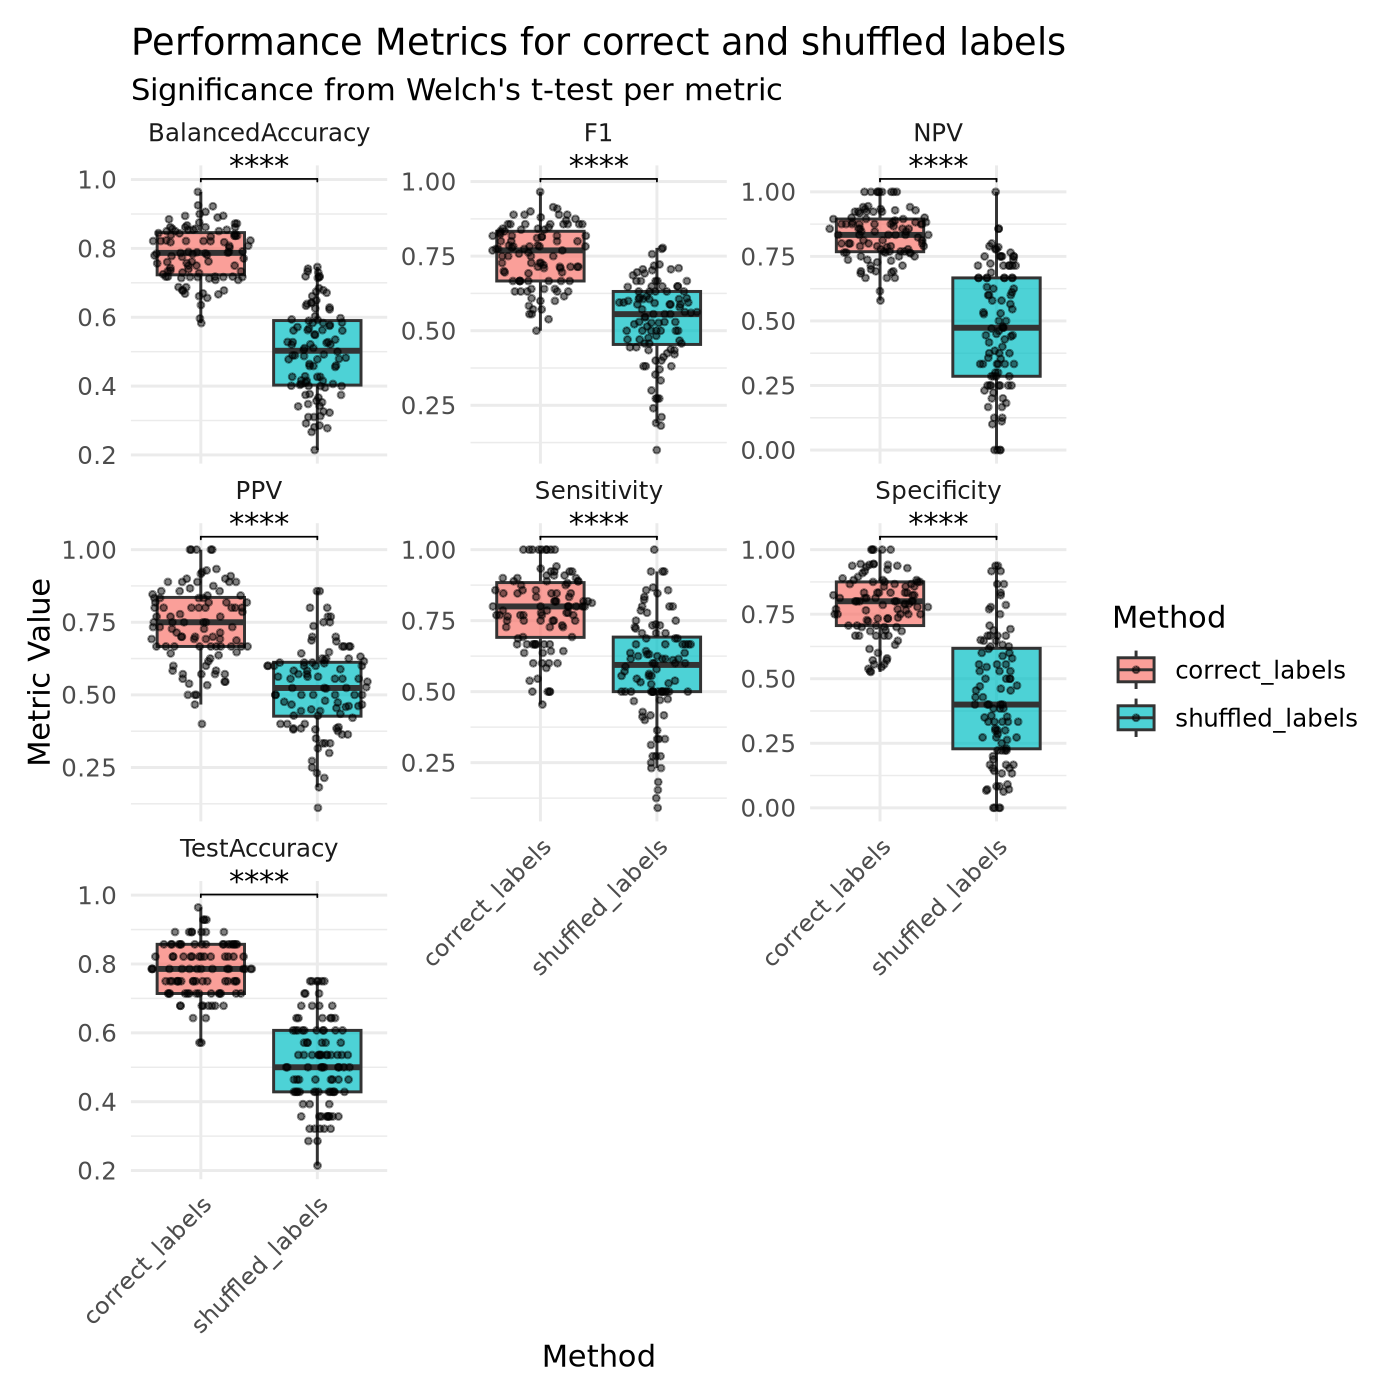

In [126]:
p.dims(7, 7)


p1 <- ggplot(metrics_long, aes(x = Method, y = Value, fill = Method)) +
  geom_boxplot(alpha = 0.7, outlier.shape = NA) +
  geom_sina(alpha = 0.5, size = 0.8) + 
  facet_wrap(~Metric, scales = "free_y") +
  stat_compare_means(
    method = "t.test",
    label = "p.signif",
    comparisons = comparisons,
    aes(label = ..p.signif.., y.position = y.position),
    tip.length = 0.01
  ) +
  coord_cartesian(clip = "off") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.margin = ggplot2::margin(10, 10, 10, 10),
    strip.text = element_text(margin = ggplot2::margin(b = 8))
  ) +
  labs(
    title = "Performance Metrics for correct and shuffled labels",
    subtitle = "Significance from Welch's t-test per metric",
    y = "Metric Value", x = "Method"
  )


p1

#### Figure 2a and SFigure 3a

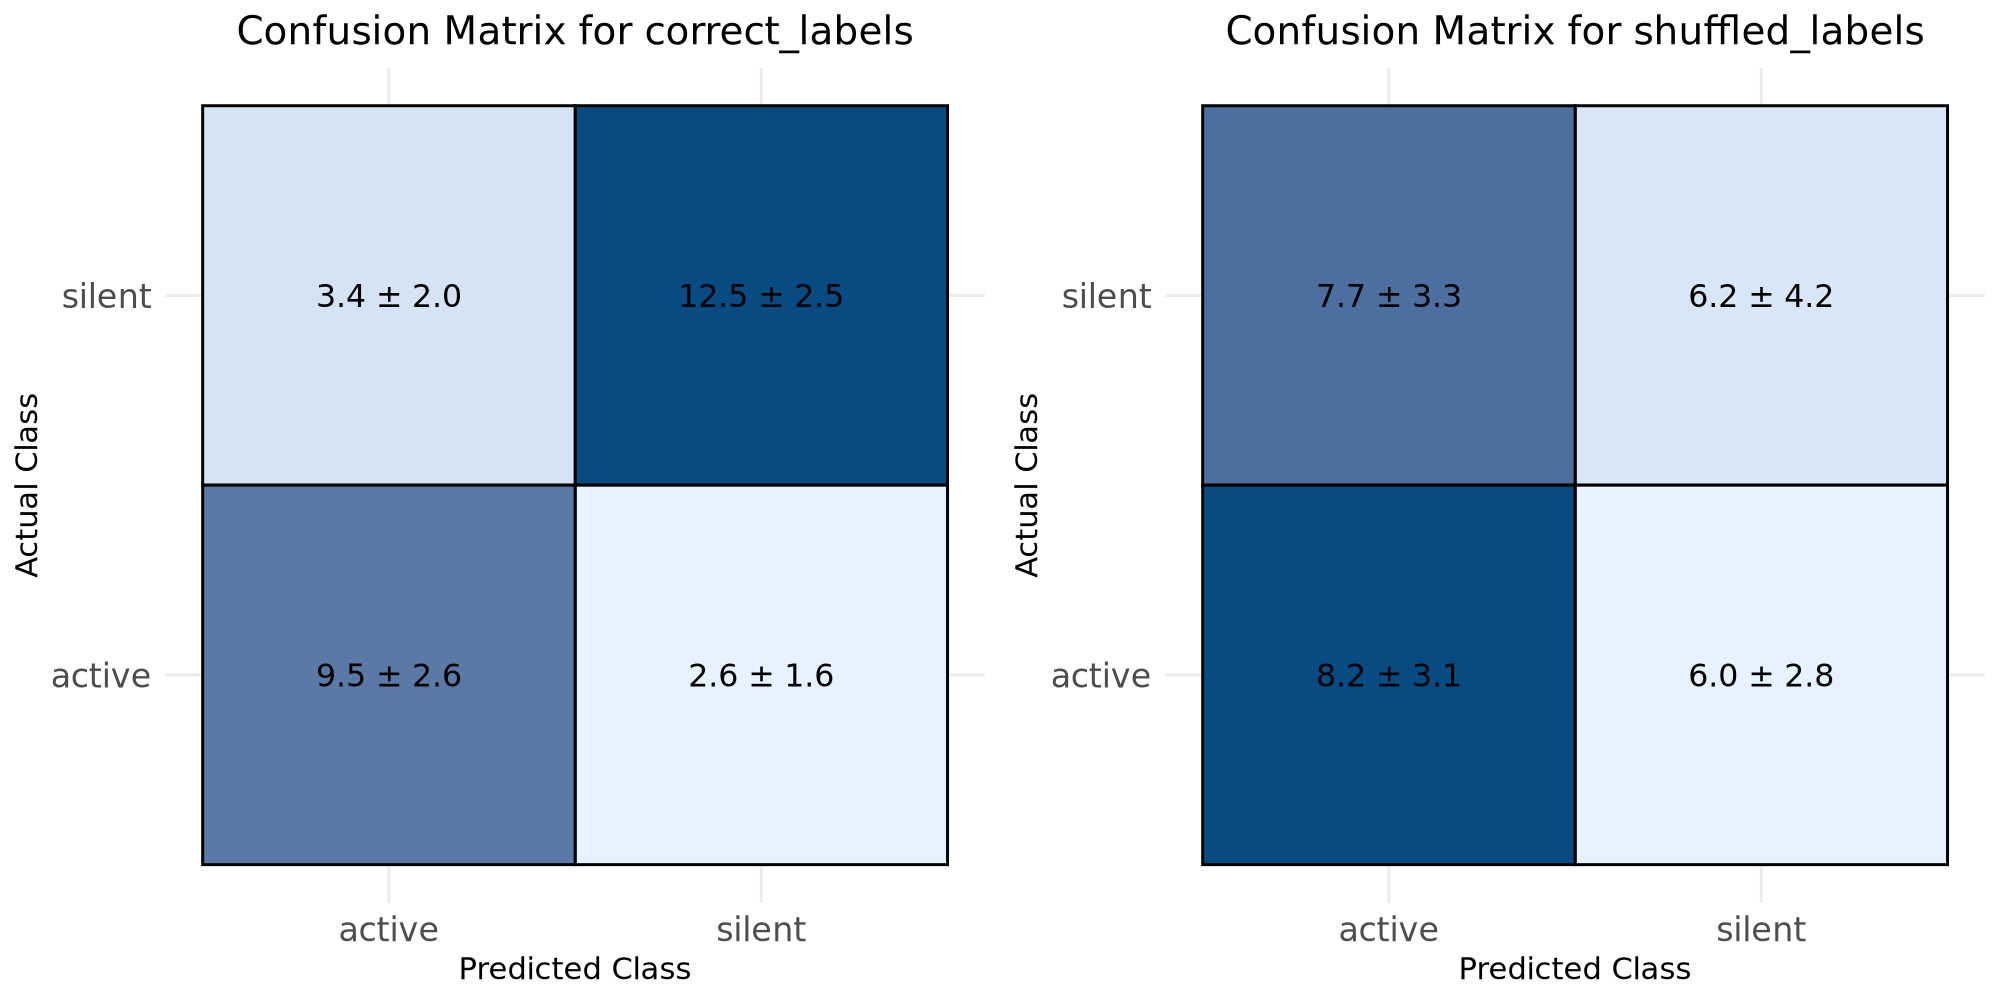

In [127]:
p.dims(10, 5)
evaluation_results <- plot_evaluation_results(results)

# 4 Apply model to the whole dataset

In [37]:
df_cleaned_full_filtered

,R.K478_r_k,E78_charge,L88_charge,Q89_charge,R90_charge,L94_charge,A95_charge,Q97_charge,N100_charge,S101_charge,⋯,pident_FliC,length_FliC,mismatch_FliC,alntmscore_foldseek,rmsd_foldseek,avg.activity,avg.binding,Exp.phenotype,Cluster_CDHit,sequence
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
SAE38355_1,1,-1,0,0,1,0,0,0,0,0,⋯,76.0,179,43,0.8947,4.831,NA,NA,NA,959,NA
SAB91600_1,1,-1,0,0,1,0,0,0,0,0,⋯,76.5,179,42,0.8943,4.899,NA,NA,NA,960,NA
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
DAB10973_1,1,-1,0,-1,1,0,0,0,0,0,⋯,35.7,126,81,0.872,3.023,NA,NA,NA,7,NA


In [38]:
df_full <- df_cleaned_full_filtered %>% select(-c(Exp.phenotype, avg.activity, avg.binding, Cluster_CDHit, sequence)) %>% na.omit()
df_full

,R.K478_r_k,E78_charge,L88_charge,Q89_charge,R90_charge,L94_charge,A95_charge,Q97_charge,N100_charge,S101_charge,⋯,N449_hydrophobicity,R.K478_hydrophobicity,pident_FlaB,length_FlaB,mismatch_FlaB,pident_FliC,length_FliC,mismatch_FliC,alntmscore_foldseek,rmsd_foldseek
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<dbl>
SAE38355_1,1,-1,0,0,1,0,0,0,0,0,⋯,1,1,37.6,101,63,76.0,179,43,0.8947,4.831
SAB91600_1,1,-1,0,0,1,0,0,0,0,0,⋯,1,1,40.5,84,50,76.5,179,42,0.8943,4.899
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
DAB10973_1,1,-1,0,-1,1,0,0,0,0,0,⋯,-1,1,26.7,101,71,35.7,126,81,0.872,3.023


In [39]:
df_full$pred_s1 <- as.vector(predict(res1, newdata = df_full))

In [40]:
cat('The probability with which the model predicts a class for each observation in the full set.')
prob_s1 <- predict(res1, newdata = df_full, type = "prob")
prob_s1


The probability with which the model predicts a class for each observation in the full set.

,active,silent
,<dbl>,<dbl>
SAE38355_1,0.662,0.338
SAB91600_1,0.642,0.358
⋮,⋮,⋮
DAB10973_1,0.618,0.382


In [41]:
prob_s1 <- prob_s1 %>% mutate(probability_s1 = if_else(active > silent, active, silent))
prob_s1

,active,silent,probability_s1
,<dbl>,<dbl>,<dbl>
SAE38355_1,0.662,0.338,0.662
SAB91600_1,0.642,0.358,0.642
⋮,⋮,⋮,⋮
DAB10973_1,0.618,0.382,0.618


In [42]:
df_full <- df_full %>% rownames_to_column(var = "protein_id")
df_cleaned_full_filtered_1 <- df_cleaned_full_filtered %>% rownames_to_column(var = "protein_id")
prob_s_1 <- prob_s1 %>% rownames_to_column(var = "protein_id")

df_full <- df_full %>% left_join(select(df_cleaned_full_filtered_1, protein_id, Exp.phenotype, avg.activity, avg.binding, Cluster_CDHit), by = "protein_id") %>% 
                       left_join(select(prob_s_1, probability_s1, protein_id )) %>%
                       column_to_rownames(var = "protein_id")


Joining with `by = join_by(protein_id)`


### SFigure 4 (reduced)

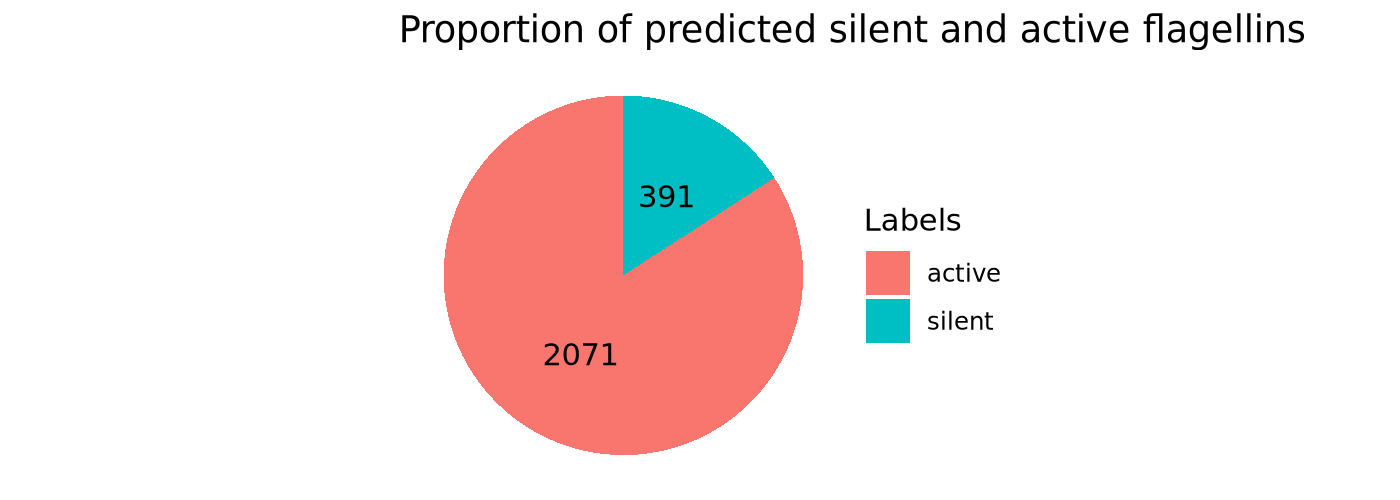

In [49]:
p.dims(7, 2.5)
df_full %>% 
    group_by(pred_s1) %>% 
    count() %>% 
    ggplot(aes(x = "", y = n, fill = pred_s1)) +
    geom_bar(stat = "identity", width = 1) +
    coord_polar("y", start = 0) +
    labs(fill = "Labels") +
    ggtitle('Proportion of predicted silent and active flagellins') +
    theme_void() +
    geom_text(aes(label = n), position = position_stack(vjust = 0.5))


In [64]:
df_full <- df_full %>% mutate(prob_zero = probability_s1 - 0.5) %>% mutate(prob_gradient = if_else(pred_s1 == "active", 0 - prob_zero, prob_zero))


### SFigure 4a (binding activity plot)

In [65]:
#ba - binding/activity
df_ba_plot <- df_full %>% filter(!is.na(Exp.phenotype)) %>% mutate(Status = if_else(pred_s1 == Exp.phenotype, 'match', 'mismatch'))


In [66]:
# for the borders; experimental data from (Clasen, 2023)
df_base = data.frame(
    xmin = c(-2.066, -6, -6),
    xmax = c(0.220993633, -2.066, -2.066),
    ymin = c(0, 0, 0.1144),
    ymax = c(3.75, 0.1144, 3.75),
    status = c('Active', 'Evader', 'Silent')
)

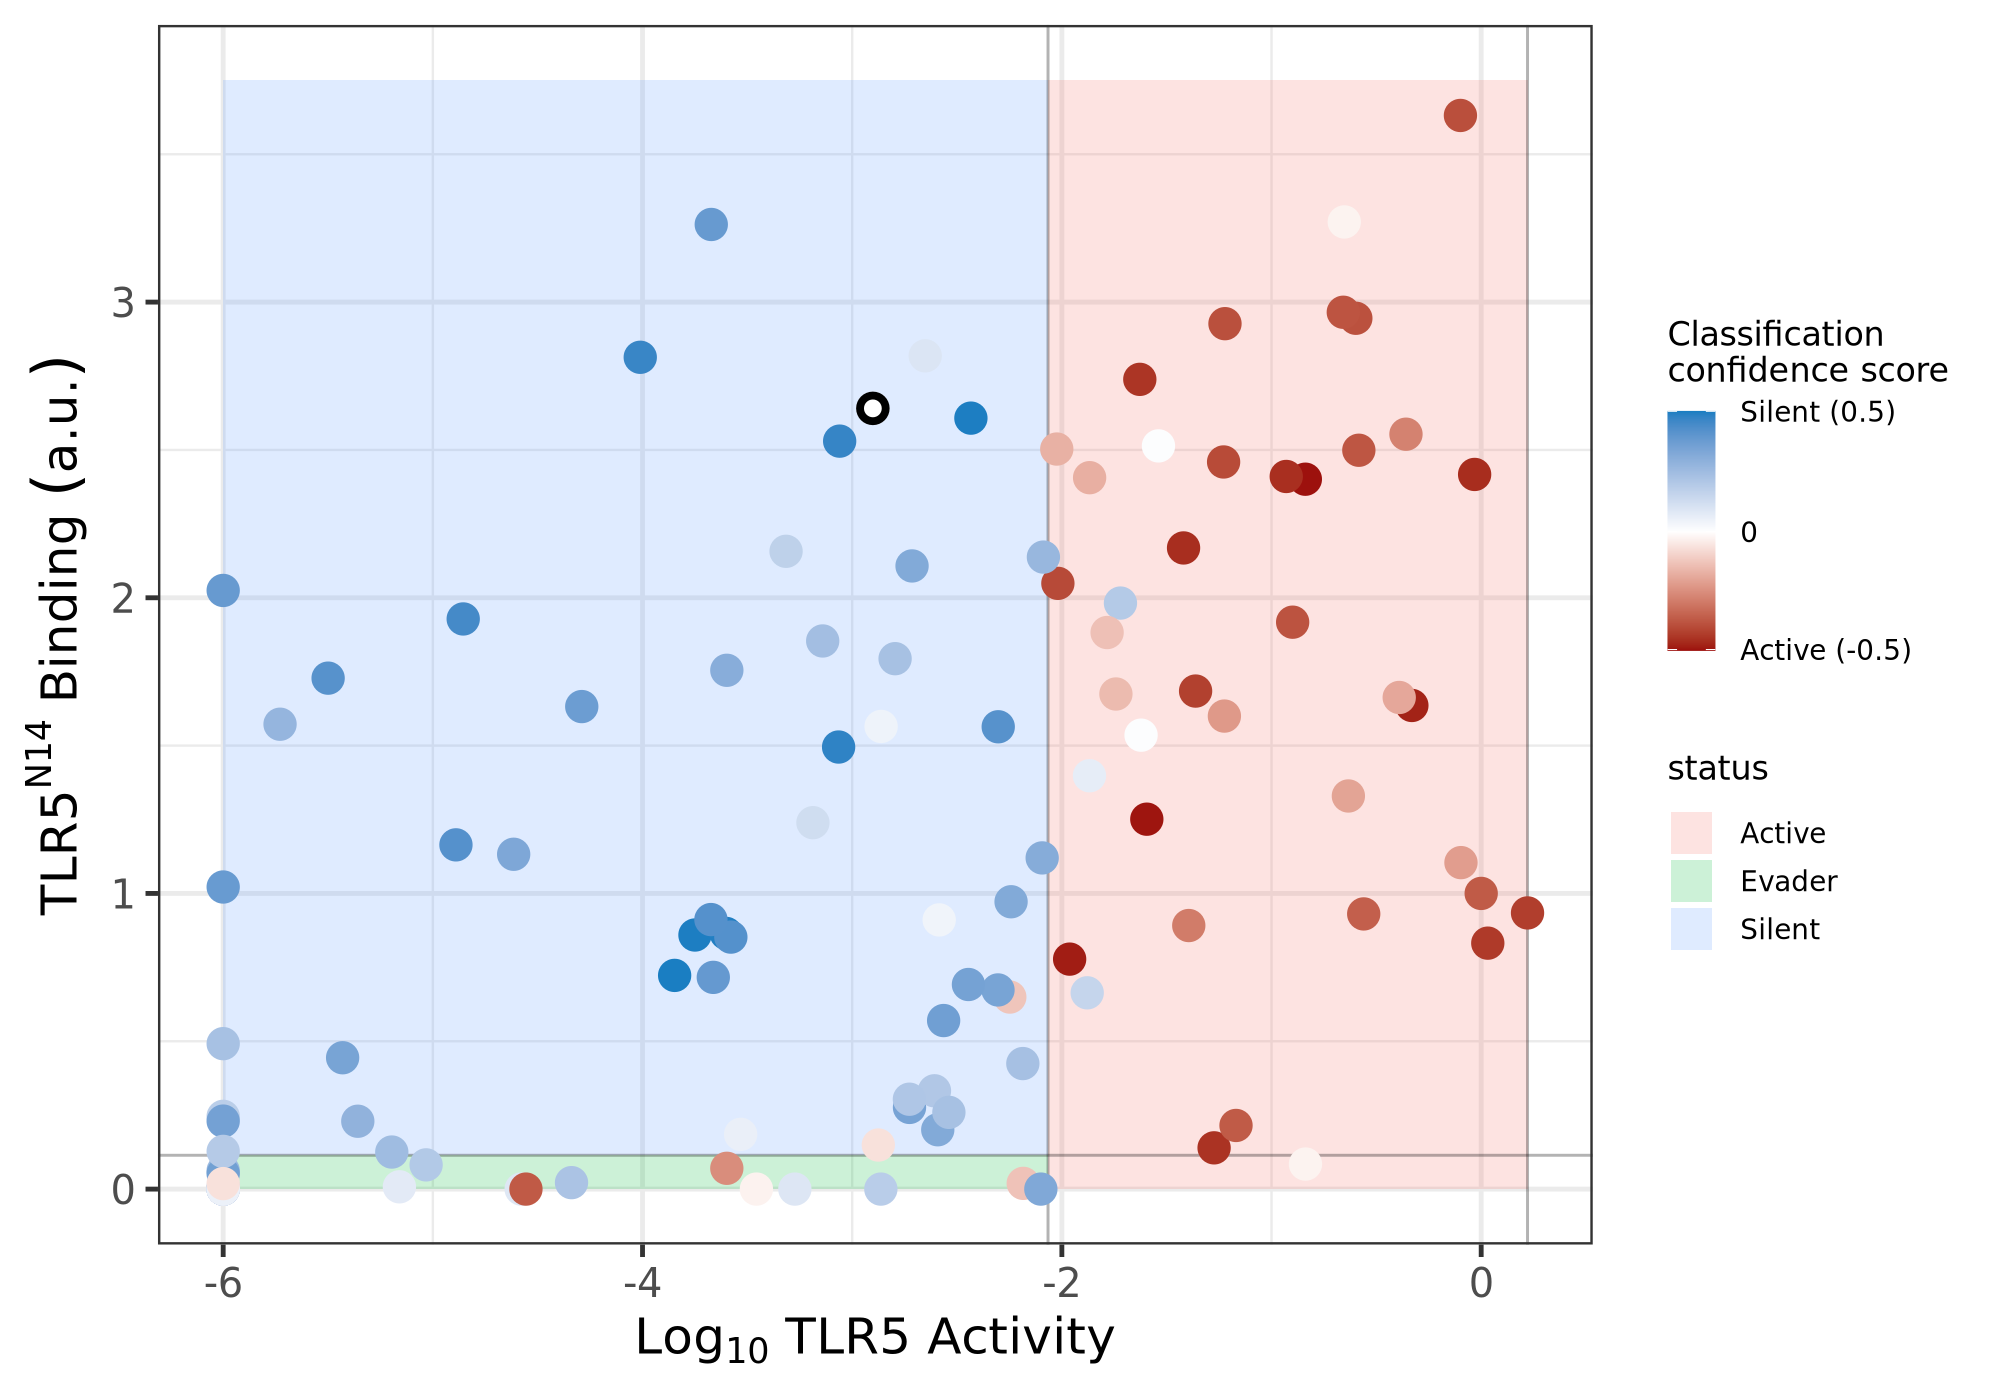

In [67]:
p.dims(10, 7)

p = df_ba_plot %>%
    ggplot(aes(avg.activity, avg.binding)) +
    geom_rect(aes(x=1, y=1, xmin = xmin, xmax = xmax, 
                  ymin = ymin, ymax=ymax, fill=status), 
              alpha=0.2, data=df_base) +
    geom_hline(yintercept = 0.1144, alpha=0.3, size=0.5) +
    geom_vline(xintercept = -2.066, alpha=0.3, size=0.5) +
    geom_vline(xintercept = 0.220993633, alpha=0.3, size=0.5) +
    geom_point(aes(color=prob_gradient, size = 0.5), alpha=1) +
    scale_color_gradient2(
        name = "Classification\nconfidence score",
        low = "#9b0a0a",      
        mid = "white", 
        high = "#1a7ec2",     
        midpoint = 0,
        # Custom breaks and labels
        breaks = c(round(min(df_ba_plot$prob_gradient, na.rm = TRUE), 2),
                   0,
                   round(max(df_ba_plot$prob_gradient, na.rm = TRUE), 2)),
        labels = c("Active (-0.5)", "0", "Silent (0.5)")
    ) +
    scale_fill_discrete('Experimental\nphenotype\n') +
    scale_x_continuous(limits = c(-6, 0.220993633)) +
    labs(x='Activity', y='Binding') +
    theme_bw(base_size = 18) +
    guides(size = "none") +
    theme(
        legend.title = element_text(size = 12),    # Smaller legend titles
        legend.text = element_text(size = 10)      # Smaller legend text
    ) +
    geom_point(data = df_ba_plot %>% filter(prob_gradient == 0),
               aes(avg.activity, avg.binding), 
               color = "black", size = 3, shape = 1, stroke = 2) +  # Black circle outline
    labs(x = expression(Log[10]~TLR5~Activity),
         y = expression(TLR5^N14~Binding~(a.u.)))

p

#### SFigure 4c

In [68]:
mixed_clusters <- df_full %>% rownames_to_column(var = 'Flagellin_ID') %>% group_by(Cluster_CDHit) %>%
    mutate(n_fla_in_cluster = n()) %>%
    filter(n_fla_in_cluster > 1) %>%
    count(pred_s1) %>%
    mutate(Cluster_CDHit = as.factor(Cluster_CDHit)) %>%
    filter(all(c("active", "silent") %in% pred_s1))

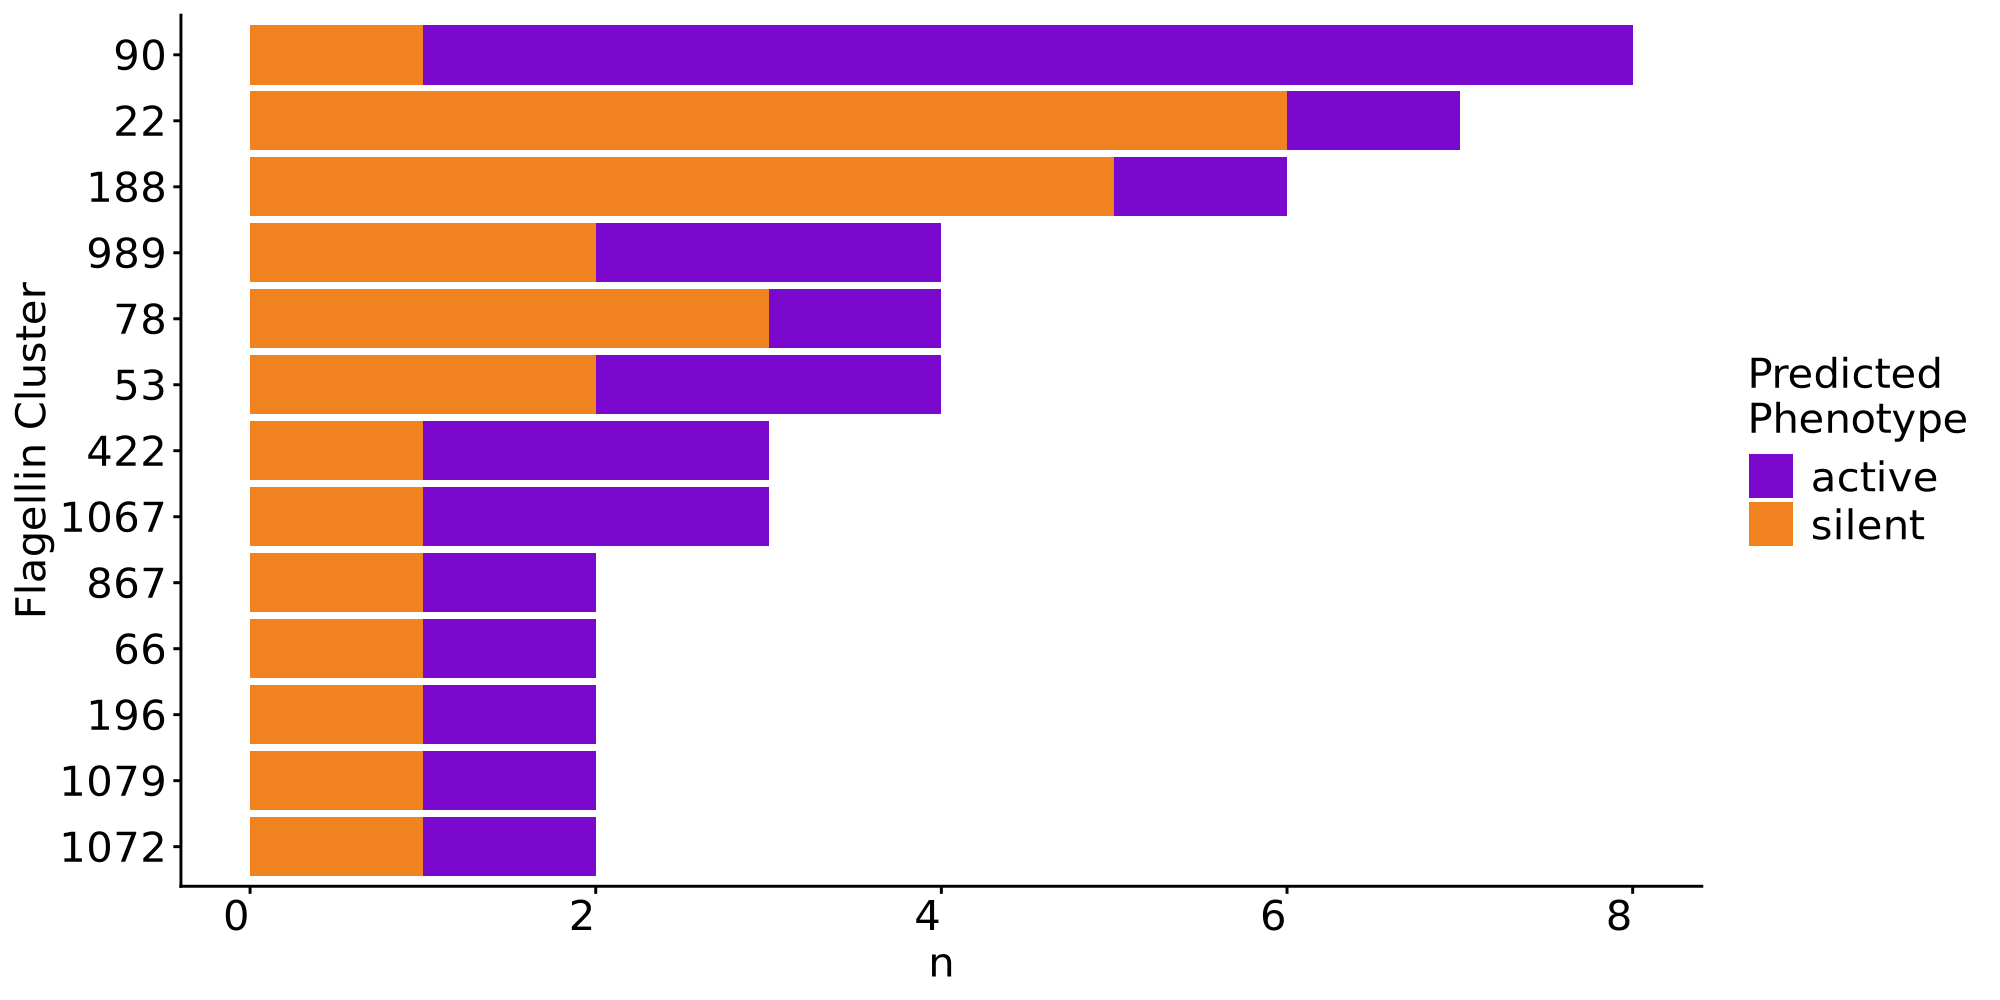

In [69]:
#options(repr.plot.width=15, repr.plot.height=15)
p.dims(10, 5)
mixed_clusters %>%
    ggplot(aes(x = reorder(Cluster_CDHit, n), y = n, fill = pred_s1)) +
        geom_bar(stat = 'identity') +
        scale_fill_manual(name = 'Predicted\nPhenotype', values = c("active" = "#7b08cd", "silent" = '#f18220')) +
        theme_classic() +
        coord_flip() +
        theme(axis.text.x = element_text(hjust = 1, vjust = 1),
          axis.text=element_text(size=15), #change font size of axis text
          axis.title=element_text(size=15), #change font size of axis titles
          legend.text=element_text(size=15), #change font size of legend text
          legend.title=element_text(size=15))+#, +
        labs(x='Flagellin Cluster', y='n') 
        
          #legend.position = 'none') #change font size of legend title

Warning message in geom_bar(stat = "identity", position = "stack", aes(color = pred_s1), :
“Ignoring unknown parameters: `size`”


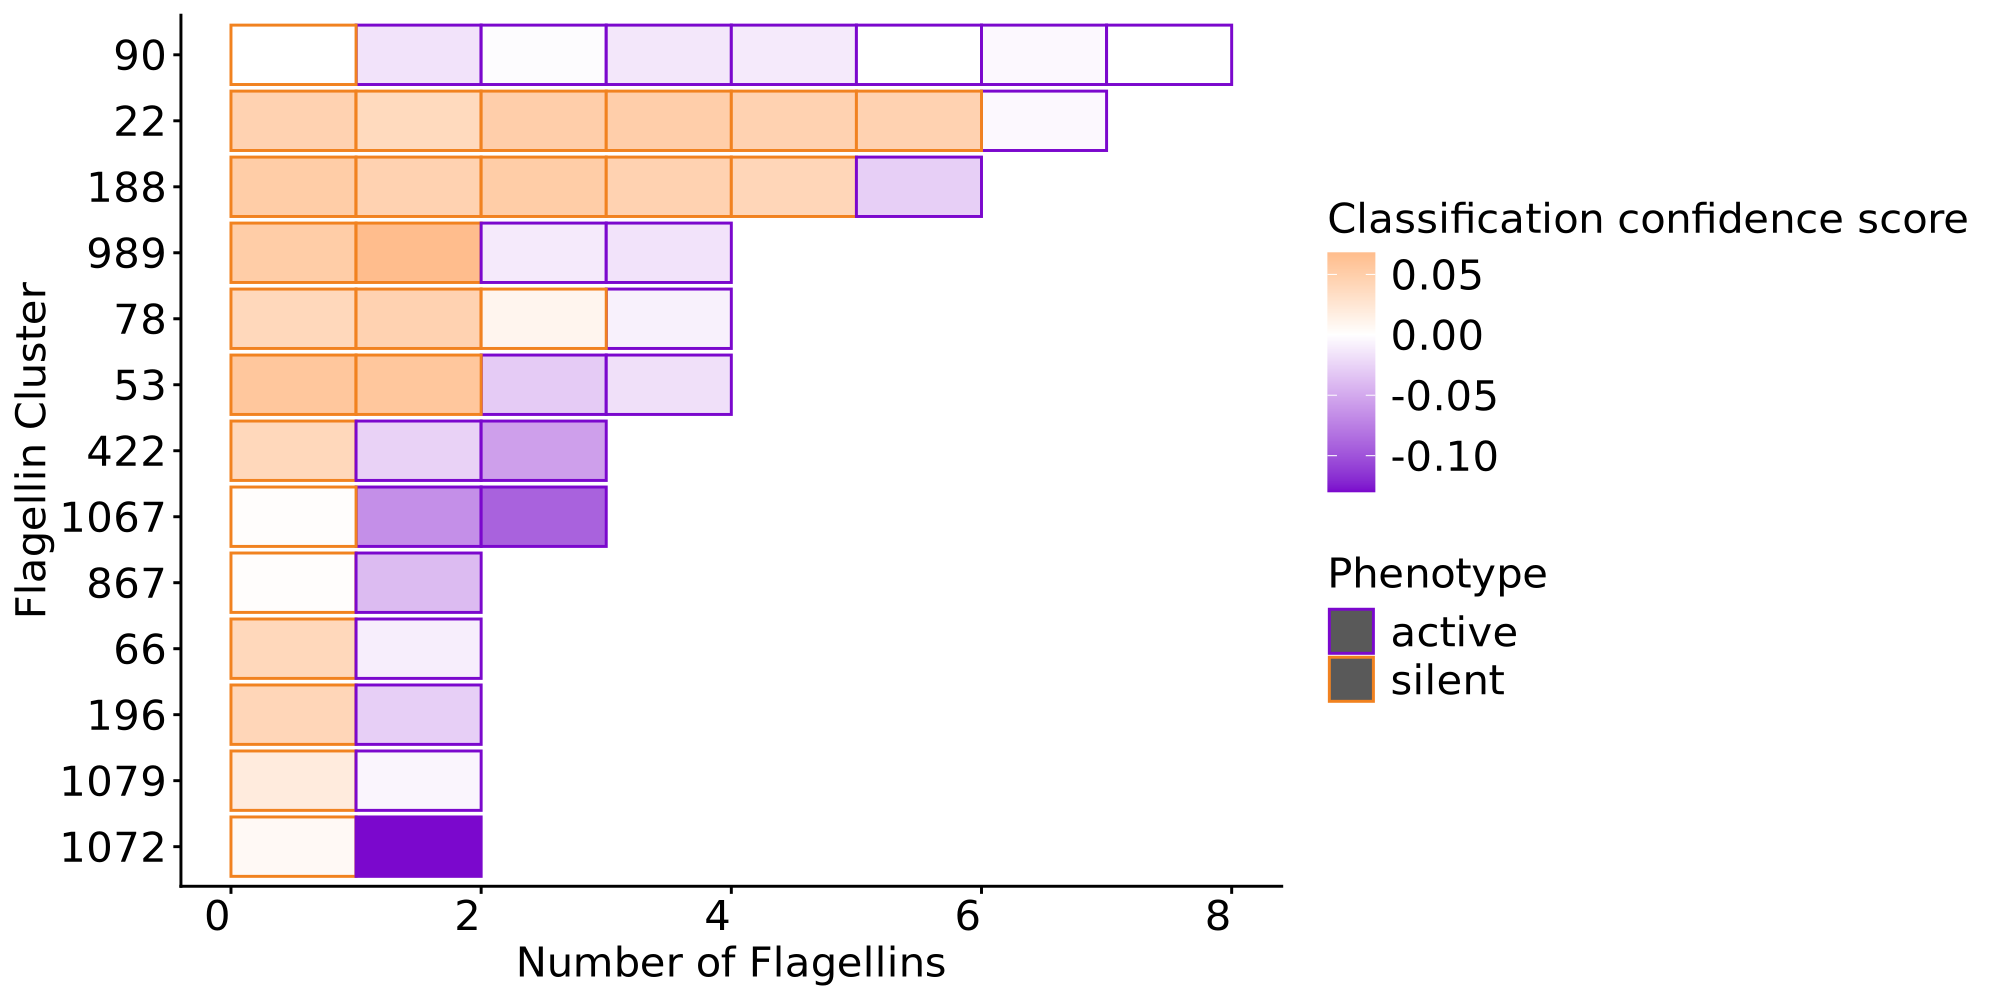

In [72]:
df_full %>% 
  select(-c(1:45)) %>% 
  filter(Cluster_CDHit %in% mixed_clusters$Cluster_CDHit) %>% 
  rownames_to_column(var = "Flagellin_ID") %>% 
  group_by(Cluster_CDHit) %>% 
  mutate(n = n()) %>%
  ggplot(aes(x = reorder(Cluster_CDHit, n), y = 1, fill = prob_gradient)) +
  geom_bar(stat = 'identity', 
           position = "stack",
           aes(color = pred_s1),
           size = 1) +              # Thick colored borders for prediction status
  scale_fill_gradient2(
    name = "Classification confidence score",
    low = '#7b08cd', 
    mid = "white", 
    high = '#f18220'
  ) +
  scale_color_manual(
    name = "Phenotype",
    values = c("active" = "#7b08cd", "silent" = '#f18220')
  ) +
  theme_classic() +
  coord_flip() +
  labs(
    x = "Flagellin Cluster", 
    y = "Number of Flagellins"
  ) +
  theme(
    axis.text.x = element_text(hjust = 1, vjust = 1),
    axis.text = element_text(size = 15),
    axis.title = element_text(size = 15),
    legend.text = element_text(size = 15),
    legend.title = element_text(size = 15),
    legend.position = "right"
  )

In [80]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Debian GNU/Linux 12 (bookworm)

Matrix products: default
BLAS/LAPACK: /tmp/global2/abogdanova/envs/R/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ggpubr_0.6.2         gridExtra_2.3        pwalign_1.2.0       
 [4] Biostrings_2.74.0    GenomeInfoDb_1.42.0  XVector_0.46.0      
 [7] IRanges_2.40.0       S4Vectors_0.44.0     BiocGenerics_0.52.0 
[10] LeyLabRMi